In [161]:
import pandas as pd
import numpy as np
import seaborn as sns


In [162]:
df = pd.read_csv("../data/customer_churn.csv")

df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1


we will first check the info of the dataset and look for any changes needed for dtypes

In [163]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


we found one - Onboard_date     900 non-null    str   we need to convert into date time dtype

In [164]:
df['Onboard_date'] = pd.to_datetime(df['Onboard_date'], dayfirst=True, format='mixed')

In [165]:
df['Onboard_date'].dtype

dtype('<M8[us]')

In [166]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Names            900 non-null    str           
 1   Age              900 non-null    float64       
 2   Total_Purchase   900 non-null    float64       
 3   Account_Manager  900 non-null    int64         
 4   Years            900 non-null    float64       
 5   Num_Sites        900 non-null    float64       
 6   Onboard_date     900 non-null    datetime64[us]
 7   Location         900 non-null    str           
 8   Company          900 non-null    str           
 9   Churn            900 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(2), str(3)
memory usage: 70.4 KB


Onboard_date     has been converted into    datetime64[us] from STR

as we can see there is no null value but still we will check for it.

In [167]:
df.isnull().sum().sum()

np.int64(0)

no null values now we will be checking for the dduplicates

In [168]:
df.duplicated().sum()

np.int64(0)

no duplicate values.

In [169]:
print("The dtypes of the dataset is properly formated")
print('Null values: ', df.isnull().sum().sum())
print('Duplicated values: ', df.duplicated().sum())

The dtypes of the dataset is properly formated
Null values:  0
Duplicated values:  0


Since this dataset is cleared we can save this dataset as cleaned data. before starting the feature creation and engineering

In [170]:
df.to_csv("../Day11_revision/cleaned_customer_churn_dataset.csv")

now lets start the feature creations

In [171]:
df.head(5)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


we can see out of all the columns the one we need to for target is going to be Churn.  A specfic feature we need to create first is identify the customer tenure in easy terms liek new, mid and old

but how will we identify that? 

In [172]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,2011-04-16 22:35:36.358888,0.166667
min,22.000000,100.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,2008-06-29 16:05:08,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,2011-03-26 09:29:36.500000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,2014-02-24 19:50:14.750000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000
std,6.127560,2408.644532,0.499921,1.274449,1.764836,NaN,0.372885


we will take the bins to be 0,3,6,9

In [173]:
df['year_tenure'] = pd.cut(df['Years'], bins=[0,3,6,9], labels=['New','Mid', 'Old'])

In [174]:
df['year_tenure'].value_counts()

year_tenure
Mid    614
Old    243
New     42
Name: count, dtype: int64

<Axes: xlabel='year_tenure', ylabel='Count'>

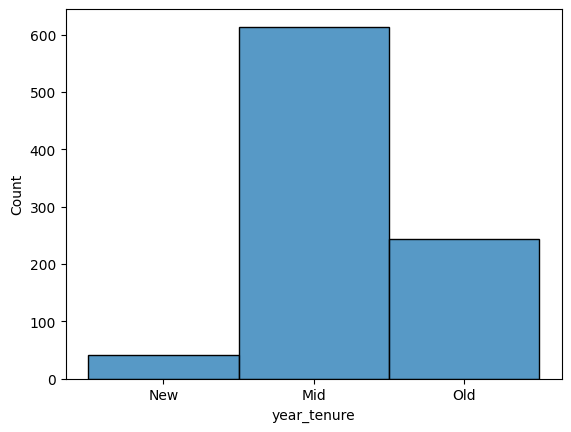

In [175]:
sns.histplot(df['year_tenure'])

In [176]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,year_tenure
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Old
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,Old
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,Old
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,Old
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,Mid


Since we are able to understand that candidate with mid years are more followed by old and last are new. we need to work on the next feature which to identify a stronger predictor.

In [177]:
df.groupby('Years')['Churn'].value_counts().sort_values(ascending=False)

Years  Churn
5.89   0        8
4.61   0        7
5.07   0        7
5.54   0        6
6.45   0        6
               ..
7.78   0        1
7.77   0        1
7.76   1        1
7.67   0        1
2.62   0        1
Name: count, Length: 509, dtype: int64

In [178]:
df.groupby('Num_Sites')['Churn'].value_counts().sort_values(ascending=True)

Num_Sites  Churn
6.0        1          1
14.0       0          1
7.0        1          2
3.0        0          2
4.0        0          4
12.0       0          5
14.0       1          5
8.0        1          8
13.0       1          8
9.0        1         19
5.0        0         22
12.0       1         27
10.0       1         34
11.0       0         37
           1         46
6.0        0         66
10.0       0         97
7.0        0        144
9.0        0        167
8.0        0        205
Name: count, dtype: int64

In [179]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,2011-04-16 22:35:36.358888,0.166667
min,22.000000,100.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,2008-06-29 16:05:08,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,2011-03-26 09:29:36.500000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,2014-02-24 19:50:14.750000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000
std,6.127560,2408.644532,0.499921,1.274449,1.764836,NaN,0.372885


Years and Num_Sites are coming out as a very strong predictor. At this stage we can create a predictor that give a stronger prediction combining but the predictor it will be much strong so here we will be using interation featuring

In [180]:
df['year_x_num_sites'] = df['Years'] * df['Num_Sites']

In [181]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,year_tenure,year_x_num_sites
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Old,57.76
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,Old,71.50
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,Old,80.04
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,Old,67.10
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,Mid,50.04


Now we need to check for the large datas that is going to create issues for with training the model such as Total_Purchase. this is going run the model in very high frequncy that the prediction can be impacted highly so we are going to use the transformation featuring to lower the values to a range where the machine can easily do the learning for the prediction.

In [182]:
df['log_total_purchase'] = np.log1p(df['Total_Purchase'])

df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,year_tenure,year_x_num_sites,log_total_purchase
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Old,57.76,9.311795
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,Old,71.50,9.385740
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,Old,80.04,9.463877


now we can see the difference using histplot

<Axes: xlabel='Total_Purchase', ylabel='Count'>

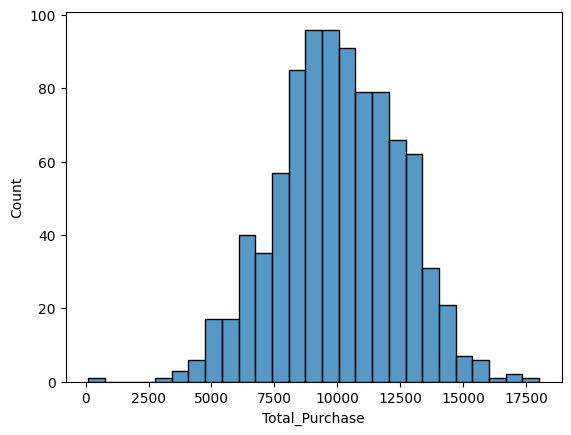

In [183]:
sns.histplot(df['Total_Purchase'])

<Axes: xlabel='log_total_purchase', ylabel='Count'>

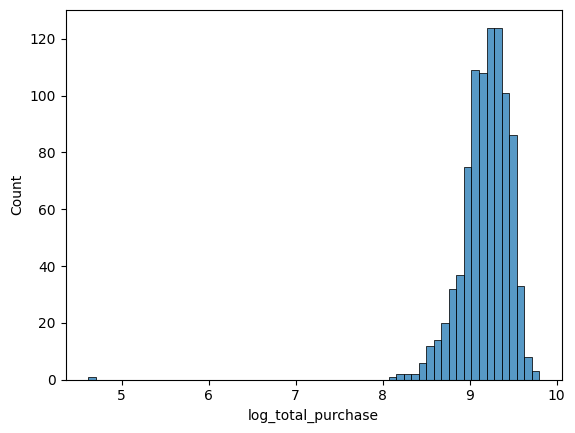

In [184]:
sns.histplot(df['log_total_purchase'])

by doing this we have got the data range in between of 8 to 10 and also found an outlier that can create massive to minimum errors in training. so now we will try to identify if this outlier is an error or a genuine entry and if we should keep it.

In [185]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn,year_x_num_sites,log_total_purchase
count,900.000000,900.000000,900.000000,900.000000,900.000000,900,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,2011-04-16 22:35:36.358888,0.166667,45.400711,9.181865
min,22.000000,100.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000,10.000000,4.615121
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,2008-06-29 16:05:08,0.000000,34.930000,9.047600
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,2011-03-26 09:29:36.500000,0.000000,43.910000,9.215016
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,2014-02-24 19:50:14.750000,0.000000,53.470000,9.372553
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000,101.500000,9.799626
std,6.127560,2408.644532,0.499921,1.274449,1.764836,NaN,0.372885,15.084907,0.298455


the min values shown is min	22.000000	100.000000	0.000000	1.000000	3.000000	2006-01-03 07:20:00	0.000000	10.000000	4.61512

so now we identify which is the value

In [186]:
df.sort_values(by="Total_Purchase").head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,year_tenure,year_x_num_sites,log_total_purchase
659,Kayla Reeves,38.0,100.00,0,5.27,5.0,2006-03-10 09:01:48,"1511 Porter Drive Amberberg, NC 44608",Stewart-Lopez,0,Mid,26.35,4.615121
371,Justin Campos,53.0,3263.00,1,2.77,9.0,2013-11-11 22:49:58,"3483 Davis Viaduct Guzmanmouth, RI 60858",Hall-Butler,0,New,24.93,8.090709
448,Lori Medina,39.0,3676.68,1,3.52,9.0,2008-07-16 11:36:45,"PSC 1874, Box 9238 APO AP 68299","Garcia, Hansen and Austin",0,Mid,31.68,8.210037


so we found it is 

659	Kayla Reeves	38.0	100.00	0	5.27	5.0	2006-03-10 09:01:48	1511 Porter Drive Amberberg, NC 44608	Stewart-Lopez	0	Mid	26.35	4.615121

since this could be genuine but in a very small value  as compared to others we opt to remove this value.

In [187]:
df = df.drop(659)

In [188]:
df.sort_values(by="Total_Purchase").head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,year_tenure,year_x_num_sites,log_total_purchase
371,Justin Campos,53.0,3263.00,1,2.77,9.0,2013-11-11 22:49:58,"3483 Davis Viaduct Guzmanmouth, RI 60858",Hall-Butler,0,New,24.93,8.090709
448,Lori Medina,39.0,3676.68,1,3.52,9.0,2008-07-16 11:36:45,"PSC 1874, Box 9238 APO AP 68299","Garcia, Hansen and Austin",0,Mid,31.68,8.210037
229,Kelly Terry,45.0,3689.95,1,5.01,11.0,2014-09-10 10:05:06,"3798 Johnson Gardens Hughesside, PR 65467","Ellis, Johnston and Sullivan",0,Mid,55.11,8.213639


In [189]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn,year_x_num_sites,log_total_purchase
count,899.000000,899.000000,899.000000,899.000000,899.000000,899,899.000000,899.000000,899.000000
mean,41.820912,10073.906151,0.481646,5.273159,8.591769,2011-04-19 00:20:37.614015,0.166852,45.421902,9.186944
min,22.000000,3263.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000,10.000000,8.090709
25%,38.000000,8508.135000,0.000000,4.450000,7.000000,2008-07-01 19:32:54.500000,0.000000,34.965000,9.048895
50%,42.000000,10050.610000,0.000000,5.210000,8.000000,2011-03-28 01:58:13,0.000000,43.920000,9.215488
75%,46.000000,11761.520000,1.000000,6.110000,10.000000,2014-02-24 22:13:10.500000,0.000000,53.480000,9.372673
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000,101.500000,9.799626
std,6.129647,2386.917245,0.499941,1.275158,1.761750,NaN,0.373051,15.079895,0.256758


since we have made the large values into a good machine learning range for total purchase we also need to check for smaller values that may create non linear  learning. for that we will be taking the years

<Axes: xlabel='Years', ylabel='Count'>

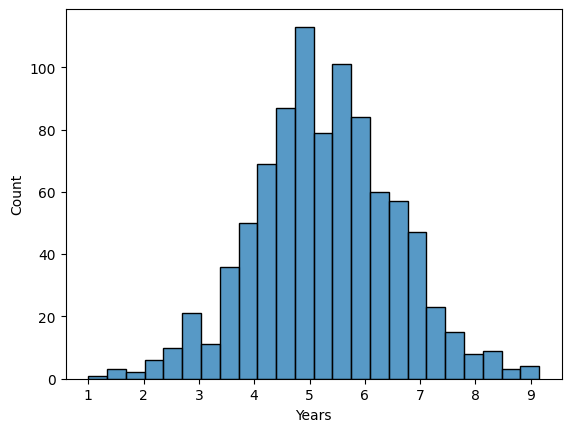

In [190]:
sns.histplot(df['Years'])

Years looks fine but jsut for a better training of the model we can use the polynomial featuring that will help in machine to not get tangled in the non linear learning

In [191]:
df['years_sqd'] = df['Years'] ** 2

<Axes: xlabel='years_sqd', ylabel='Count'>

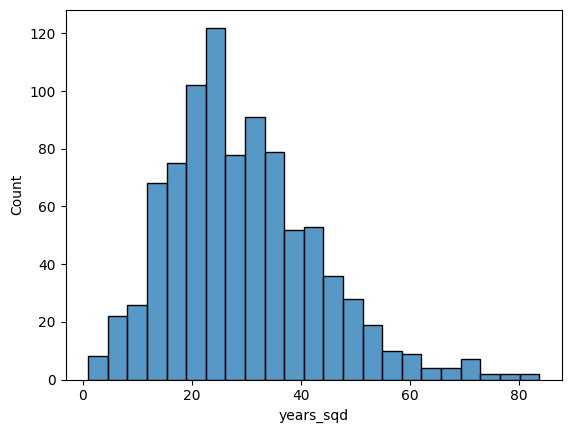

In [192]:
sns.histplot(df['years_sqd'])

althought this featuring has be done successfully but it feels like this can not be much of help as the data show is much left skewed. then the previous correctly balanced. Years so we are going to drop this feature 

In [193]:
df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,year_tenure,year_x_num_sites,log_total_purchase,years_sqd
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Old,57.76,9.311795,52.1284
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,Old,71.50,9.385740,42.2500
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,Old,80.04,9.463877,44.4889


In [194]:
df = df.drop('years_sqd', axis= 1)

In [195]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,year_tenure,year_x_num_sites,log_total_purchase
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Old,57.76,9.311795
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,Old,71.50,9.385740
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,Old,80.04,9.463877
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,Old,67.10,8.988666
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,Mid,50.04,9.126152


at this time we are at the best possible state with clean data set and enough engineered features. now we will be splitting the dataset into features and Target

In [196]:
X = df.drop('Churn', axis=1)

y = df['Churn']


In [197]:
X.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,year_tenure,year_x_num_sites,log_total_purchase
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,Old,57.76,9.311795
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,Old,71.50,9.385740
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",Old,80.04,9.463877


In [198]:
y.shape

(899,)

In [199]:
X.shape

(899, 12)

lets start with traing and splitting of the data

In [200]:
from sklearn.model_selection import train_test_split

In [201]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=.20, random_state=42
)

In [202]:
print('X_train Shape: ', X_train.shape)
print('y_train Shape: ', y_train.shape)
print('X_test Shape: ', X_test.shape)
print('y_test Shape: ', y_test.shape)

X_train Shape:  (719, 12)
y_train Shape:  (719,)
X_test Shape:  (180, 12)
y_test Shape:  (180,)


feature and target splitting is done without any dataleaks. we also created the training and test sets. now will move on to separating numeric and categorical fearture, pipleline creation

In [203]:
df.dtypes

Names                            str
Age                          float64
Total_Purchase               float64
Account_Manager                int64
Years                        float64
Num_Sites                    float64
Onboard_date          datetime64[us]
Location                         str
Company                          str
Churn                          int64
year_tenure                 category
year_x_num_sites             float64
log_total_purchase           float64
dtype: object

In [204]:
numeric_features = ['Age', 'Total_Purchase', 'Years', 'Num_Sites',
       'year_x_num_sites', 'log_total_purchase']

catgorical_features = [
    'Account_Manager',
    'year_tenure'
]

In [205]:
numeric_features

['Age',
 'Total_Purchase',
 'Years',
 'Num_Sites',
 'year_x_num_sites',
 'log_total_purchase']

In [206]:
catgorical_features

['Account_Manager', 'year_tenure']

numeric and categorical features created now we will be createing the preprocessor

In [207]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [208]:
prepro = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(drop='if_binary'),
            catgorical_features
        )
    ]
)

preprocessor create now we will be creating the pipeline for the logistic regression

In [209]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [210]:
logR_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', LogisticRegression())
])


pipeline for Logistic regression is created now we will be training and predicting the dataset

In [211]:
logR_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [212]:
pred_logR = logR_pp.predict(X_test)

now we will be check how correct is our model with the help of classification report

In [213]:
from sklearn.metrics import classification_report

In [214]:
print('Classification Report for logistic Regression: \n', classification_report(y_test, pred_linR))

Classification Report for logistic Regression: 
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       148
           1       0.76      0.59      0.67        32

    accuracy                           0.89       180
   macro avg       0.84      0.78      0.80       180
weighted avg       0.89      0.89      0.89       180



now we will quickly training, predict and check the result of other models such as random forest, gradientboosting, XGboost, KNN, catboost, lightGBM

Starting with Random Forest 

In [215]:
from sklearn.ensemble import RandomForestClassifier

In [216]:
RFC_pp = Pipeline([
    ('preprocessor', prepro),
    ('model',  RandomForestClassifier(random_state=42))
])

In [217]:
RFC_pp.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [218]:
pred_RFC = RFC_pp.predict(X_test)


In [219]:
print('Classification Report for Random Forest Classifier: \n', classification_report(y_test, pred_RFC))

Classification Report for Random Forest Classifier: 
               precision    recall  f1-score   support

           0       0.88      0.97      0.92       148
           1       0.71      0.38      0.49        32

    accuracy                           0.86       180
   macro avg       0.79      0.67      0.70       180
weighted avg       0.85      0.86      0.84       180



Now we will be doing for Gradient boosting

In [220]:
from sklearn.ensemble import GradientBoostingClassifier

In [221]:
GBR_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', GradientBoostingClassifier(random_state=42))
])

In [222]:
GBR_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [223]:
pred_GBR = GBR_pp.predict(X_test)

print('Classification Report for Gradient boosting Classifier: \n', classification_report(y_test, pred_GBR))

Classification Report for Gradient boosting Classifier: 
               precision    recall  f1-score   support

           0       0.90      0.96      0.93       148
           1       0.74      0.53      0.62        32

    accuracy                           0.88       180
   macro avg       0.82      0.75      0.77       180
weighted avg       0.88      0.88      0.88       180



now we will do KNN

In [224]:
from sklearn.neighbors import KNeighborsClassifier

In [225]:
KNN_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', KNeighborsClassifier())
])

In [226]:
KNN_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [227]:
pred_KNN = KNN_pp.predict(X_test)

print('Classification Report for Kneighbors Classifier: \n', classification_report(y_test, pred_KNN))

Classification Report for Kneighbors Classifier: 
               precision    recall  f1-score   support

           0       0.87      0.94      0.91       148
           1       0.57      0.38      0.45        32

    accuracy                           0.84       180
   macro avg       0.72      0.66      0.68       180
weighted avg       0.82      0.84      0.83       180



lets do SVM (Support vector machine)

In [228]:
from sklearn.svm import SVC

In [229]:
SVC_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', SVC(random_state=42))
])

In [230]:
SVC_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [231]:
pred_SVC = SVC_pp.predict(X_test)

print('Classification Report for Support vector Classifier: \n', classification_report(y_test, pred_SVC))

Classification Report for Support vector Classifier: 
               precision    recall  f1-score   support

           0       0.88      0.97      0.92       148
           1       0.72      0.41      0.52        32

    accuracy                           0.87       180
   macro avg       0.80      0.69      0.72       180
weighted avg       0.85      0.87      0.85       180



lets do XGBoost

In [232]:
from xgboost import XGBClassifier


In [233]:
XGB_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', XGBClassifier(random_state=42, eval_metric = 'logloss'))
])

In [234]:
XGB_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [235]:
pred_XGB = XGB_pp.predict(X_test)

print('Classification Report for XGBoost Classifier: \n', classification_report(y_test, pred_XGB))


Classification Report for XGBoost Classifier: 
               precision    recall  f1-score   support

           0       0.88      0.93      0.91       148
           1       0.58      0.44      0.50        32

    accuracy                           0.84       180
   macro avg       0.73      0.68      0.70       180
weighted avg       0.83      0.84      0.84       180



lets do lightGBM

In [236]:
from lightgbm import LGBMClassifier

In [237]:
LGBM_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', LGBMClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1))
])

In [238]:
LGBM_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [239]:
pred_LGBM = LGBM_pp.predict(X_test)

print('Classification Report for LightGBM Classifier: \n', classification_report(y_test, pred_LGBM))

Classification Report for LightGBM Classifier: 
               precision    recall  f1-score   support

           0       0.90      0.93      0.91       148
           1       0.59      0.50      0.54        32

    accuracy                           0.85       180
   macro avg       0.74      0.71      0.73       180
weighted avg       0.84      0.85      0.84       180



d:\advanced-data-wrangling-lab\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Now lets do for CATBoost

In [240]:
from catboost import CatBoostClassifier

In [241]:
CATBC_pp = Pipeline((
    ('preprocessor', prepro),
    ('model', CatBoostClassifier(
        random_state=42,
        iterations=100,
        learning_rate=0.1,
        verbose=0
    ))
))

In [245]:
CATBC_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [246]:
pred_CATBC = CATBC_pp.predict(X_test)

print('Classification Report for CATBoost Classifier: \n', classification_report(y_test, pred_CATBC))


Classification Report for CATBoost Classifier: 
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       148
           1       0.74      0.44      0.55        32

    accuracy                           0.87       180
   macro avg       0.81      0.70      0.74       180
weighted avg       0.86      0.87      0.86       180



we have done, 'LogisticRegression', 'RandomForestClassifier', 'GradientBoostingClassifier', 'KNeighborsClassifier','SVC', 'Xgboost', 'LightGBM', 'CATBoost' -  now we will compare the data and check which one is predicting the best

In [266]:
Score = {
        'Model' : ['LogisticRegression', 'RandomForestClassifier', 'GradientBoostingClassifier', 'KNeighborsClassifier','SVC', 'Xgboost', 'LightGBM', 'CATBoost'],
        'Recall' : [ 0.59  , 0.38, 0.53 , 0.38, 0.41, 0.44, 0.50, 0.44]
}

In [267]:
Comparison = pd.DataFrame(Score)

Comparison.sort_values(by ='Recall', ascending=False)

,Model,Recall
0,LogisticRegression,0.59
2,GradientBoostingClassifier,0.53
6,LightGBM,0.50
5,Xgboost,0.44
7,CATBoost,0.44
4,SVC,0.41
3,KNeighborsClassifier,0.38
1,RandomForestClassifier,0.38


Now we have found that best model having the best the reacall value is Logistic regression. that is 59%. now we are going to see if we can get better recall if we adjust the recall.

In [263]:
print('classification_report for logistic Regression: \n ', classification_report(y_test , pred_logR))

classification_report for logistic Regression: 
                precision    recall  f1-score   support

           0       0.92      0.96      0.94       148
           1       0.76      0.59      0.67        32

    accuracy                           0.89       180
   macro avg       0.84      0.78      0.80       180
weighted avg       0.89      0.89      0.89       180



we wil first check the confusion matrix for prediction of the logistic regresion

In [264]:
from sklearn.metrics import confusion_matrix

In [265]:
print(confusion_matrix(y_test, pred_logR))

[[142   6]
 [ 13  19]]


In [270]:
y_test.shape

(180,)

In [274]:
print("X_test:", len(X_test))
print("y_test:", len(y_test))
print("Predictions:", len(pred_logR))
print("Results:", len(results))

X_test: 180
y_test: 180
Predictions: 180
Results: 899


In [275]:
results  = X_test.copy()

results['actual'] = y_test

results['predicted'] = pred_logR

In [276]:
results.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,year_tenure,year_x_num_sites,log_total_purchase,actual,predicted
332,Nicole Jacobson,41.0,8783.13,1,6.20,7.0,2009-08-10 16:00:31,"029 Bill Alley Apt. 087 West Kenneth, UT 32896","Hoffman, Leach and Smith",Old,43.40,9.080702,0,0
812,Kenneth Wilkerson,42.0,11670.32,0,5.51,7.0,2014-08-05 21:37:57,Unit 8005 Box 5636 DPO AA 90315-7695,"Aguilar, Kelly and Fuentes",Mid,38.57,9.364890,0,0
745,Robin Sanchez,45.0,12200.96,1,4.70,6.0,2007-07-04 07:12:42,"2464 Cynthia Haven Apt. 333 Cynthiaport, FM 93220","Arellano, Smith and Lang",Mid,28.20,9.409352,0,0


In [277]:
wrong_pred = results[
    results['actual'] != results['predicted']
]

In [287]:
wrong_pred.groupby('actual')['predicted'].value_counts()

actual  predicted
0       1             6
1       0            13
Name: count, dtype: int64

As we can see that we 6 False Positives and 13 false negatives.  which is dangerous for the business.

we will also take teh correct predictions for the comparisons

In [288]:
Correct_pred = results[
    results['actual'] == results['predicted']
]

In [289]:
wrong_pred.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,year_x_num_sites,log_total_purchase,actual,predicted
count,19.000000,19.000000,19.000000,19.000000,19.000000,19,19.000000,19.000000,19.000000,19.000000
mean,43.473684,10427.513158,0.526316,5.962105,9.473684,2011-11-17 00:49:18.789473,56.416842,9.227107,0.684211,0.315789
min,29.000000,6351.790000,0.000000,4.260000,6.000000,2006-04-03 00:11:53,35.160000,8.756649,0.000000,0.000000
25%,39.500000,9045.875000,0.000000,5.140000,9.000000,2009-09-27 12:01:49,46.155000,9.109392,0.000000,0.000000
50%,45.000000,10793.110000,1.000000,5.700000,9.000000,2011-12-26 22:06:03,54.090000,9.286756,1.000000,0.000000
75%,48.500000,11843.950000,1.000000,6.475000,10.500000,2014-11-16 08:41:19,64.355000,9.379400,1.000000,1.000000
max,54.000000,13731.450000,1.000000,8.360000,12.000000,2016-12-28 04:07:38,81.500000,9.527517,1.000000,1.000000
std,7.010852,2282.452480,0.512989,1.220508,1.428613,NaN,14.106893,0.237344,0.477567,0.477567


In [290]:
Correct_pred.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,year_x_num_sites,log_total_purchase,actual,predicted
count,161.000000,161.000000,161.000000,161.000000,161.000000,161,161.000000,161.000000,161.000000,161.000000
mean,42.583851,10123.589068,0.472050,5.164348,8.291925,2011-02-13 10:34:36.509316,42.920124,9.191192,0.118012,0.118012
min,22.000000,4316.730000,0.000000,1.660000,3.000000,2006-01-03 20:57:16,11.620000,8.370485,0.000000,0.000000
25%,38.000000,8662.180000,0.000000,4.500000,7.000000,2008-06-09 15:15:27,32.620000,9.066837,0.000000,0.000000
50%,43.000000,10133.360000,0.000000,5.060000,8.000000,2011-02-19 18:04:28,41.040000,9.223687,0.000000,0.000000
75%,47.000000,11758.690000,1.000000,6.010000,9.000000,2013-08-24 22:54:43,50.600000,9.372433,0.000000,0.000000
max,58.000000,16371.420000,1.000000,8.970000,13.000000,2016-12-02 22:38:03,89.700000,9.703353,1.000000,1.000000
std,6.363528,2421.447493,0.500776,1.288080,1.752283,NaN,14.879916,0.260732,0.323629,0.323629


Now we will take the probalbilites of the logR pipeline and make dataframe of the the probilities

In [291]:
probabilities = logR_pp.predict_proba(X_test)


In [294]:
Threshold = .05

df_prob = pd.DataFrame(
    probabilities,
    columns=['Stay proba', 'churn Proba']
)

In [296]:
df_prob

,Stay proba,churn Proba
0,0.990244,0.009756
1,0.991421,0.008579
2,0.996903,0.003097
3,0.997378,0.002622
4,0.349435,0.650565
...,...,...
175,0.983695,0.016305
176,0.581052,0.418948
177,0.906331,0.093669
178,0.979857,0.020143


In [298]:
churn_proba = probabilities[:,1]

print(len(churn_proba))


180


In [311]:
Threshold = 0.2

pred_proba = (churn_proba >=Threshold).astype(int)

In [312]:
print('Threshold  Value: ', Threshold)
print(confusion_matrix(y_test, pred_proba))
print(classification_report(y_test, pred_proba))

Threshold  Value:  0.2
[[131  17]
 [  7  25]]
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       148
           1       0.60      0.78      0.68        32

    accuracy                           0.87       180
   macro avg       0.77      0.83      0.80       180
weighted avg       0.89      0.87      0.87       180



In [313]:
print(confusion_matrix(y_test, pred_logR))
print('classification_report for logistic Regression: \n ', classification_report(y_test , pred_logR))

[[142   6]
 [ 13  19]]
classification_report for logistic Regression: 
                precision    recall  f1-score   support

           0       0.92      0.96      0.94       148
           1       0.76      0.59      0.67        32

    accuracy                           0.89       180
   macro avg       0.84      0.78      0.80       180
weighted avg       0.89      0.89      0.89       180



with Threshold adjust we are able to get the recall value upto 69 % and we were able to catch 6 more customers from churning.